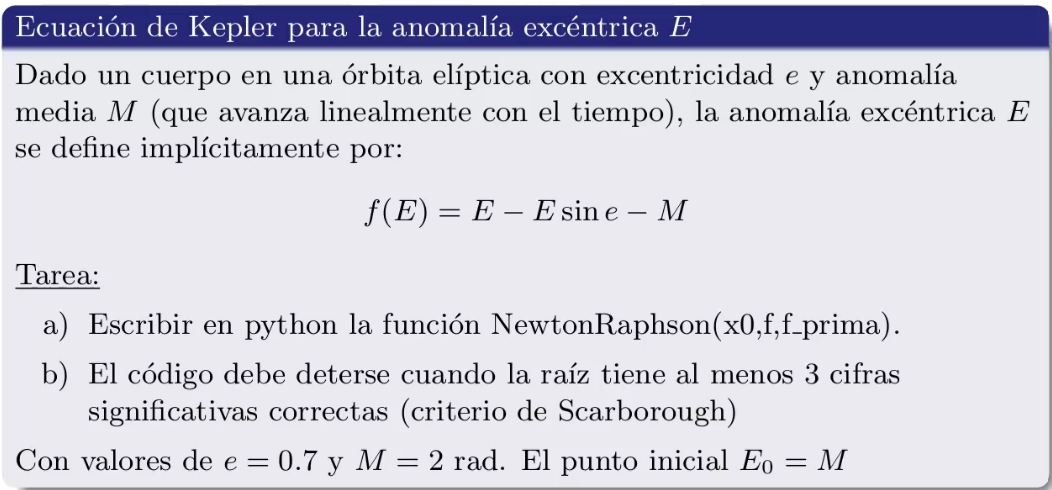

In [4]:
#Eduardo Perez
import math

e, M = 0.7, 2

def f(E):
    return E - (E*math.sin(e)) - M

def fPrime(E):
    return 1 - math.sin(e)
    
def NewtonRaphson(x0, f, fPrime):
    m = 3
    eS = 0.5*(10**(2-m))

    eA, xCurrent, it = 100, x0, 0

    while eA > eS:
        xNew = xCurrent - (f(xCurrent) / fPrime(xCurrent))
        eA = abs((xNew-xCurrent) / xNew)*100
        it += 1

        if eA == 0.0:
            break

        xCurrent = xNew

    return xNew

root = NewtonRaphson(M, f, fPrime)

print(f"La anomalía excéntrica es: {root:.6} rad")
    

La anomalía excéntrica es: 5.62141 rad


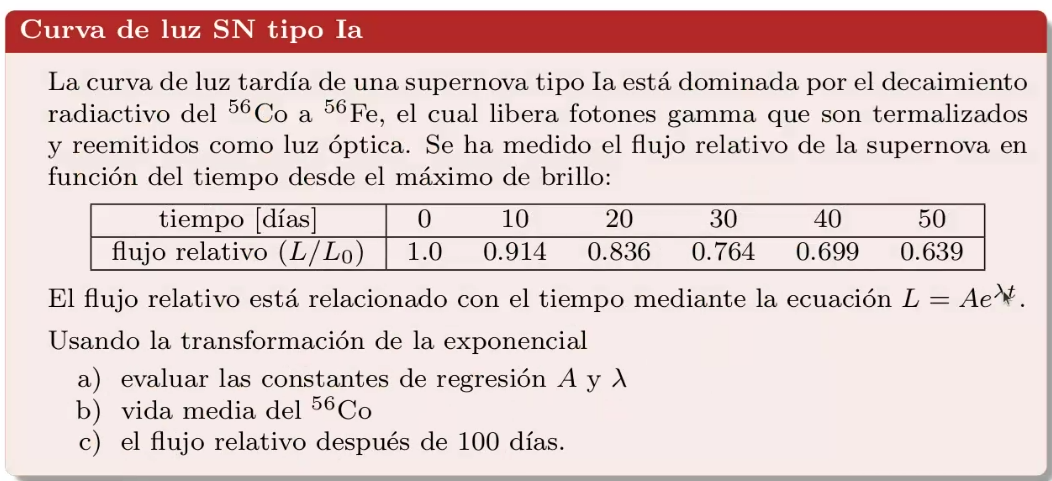

In [10]:
#Eduardo Perez
import numpy as np

t = np.array([0, 10, 20, 30, 40, 50])
L = np.array([1.0, 0.914, 0.836, 0.764, 0.699, 0.639])

X, Y = t, np.log(L)
n = len(X)

sumX, sumY, sumX2, sumXY = np.sum(X), np.sum(Y), np.sum(X**2), np.sum(X*Y)

a1 = (n*sumXY - sumX*sumY)/(n*sumX2-sumX**2)
a0 = np.mean(Y) - a1*np.mean(X)

lambd = a1
A = np.exp(a0)

print("a)")
print(f"Las constantes son A = {A} y lambda = {lambd}")

print("b)")
TAU = -1/lambd
print(f"La vida media es de {TAU} días")

print("c)")
L100 = A*np.exp(lambd*100)
print(f"El flujo relativo a los 100 días es de {L100}")

a)
Las constantes son A = 0.9998143917904035 y lambda = -0.008953869813149178
b)
La vida media es de 111.68355368887016 días
c)
El flujo relativo a los 100 días es de 0.40837369414504743


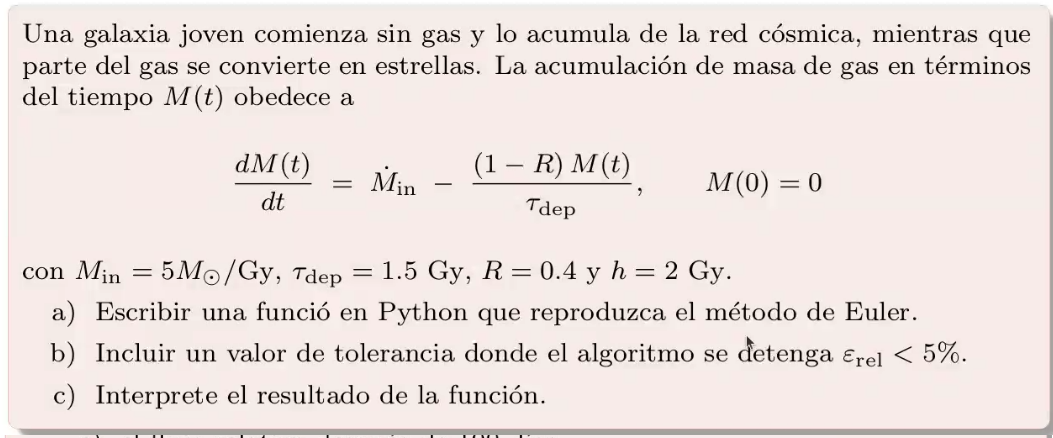

In [13]:
#Eduardo Perez
MDotIn, tauDep, R, h = 5, 1.5, 0.4, 2 #tauDep = finishing time

def f(M):
    return MDotIn - ((1-R) * M)/tauDep

def eulerMethod(M0, h, tolerance):
    MCurrent, tNow, errorRel, it = M0, 0, 100, 0

    while errorRel > tolerance:
        MNew = MCurrent + f(MCurrent)*h
        tNow += h
        it += 1

        if MNew != 0:
            errorRel = abs((MNew - MCurrent)/MNew)*100

        MCurrent = MNew

    return tNow, MCurrent

tFinal, MFinal = eulerMethod(M0=0, h=h, tolerance=5)
print(f"La galaxia logra el equilibrio en t = {tFinal} Gy con M = {MFinal}")

La galaxia logra el equilibrio en t = 6 Gy con M = 12.4


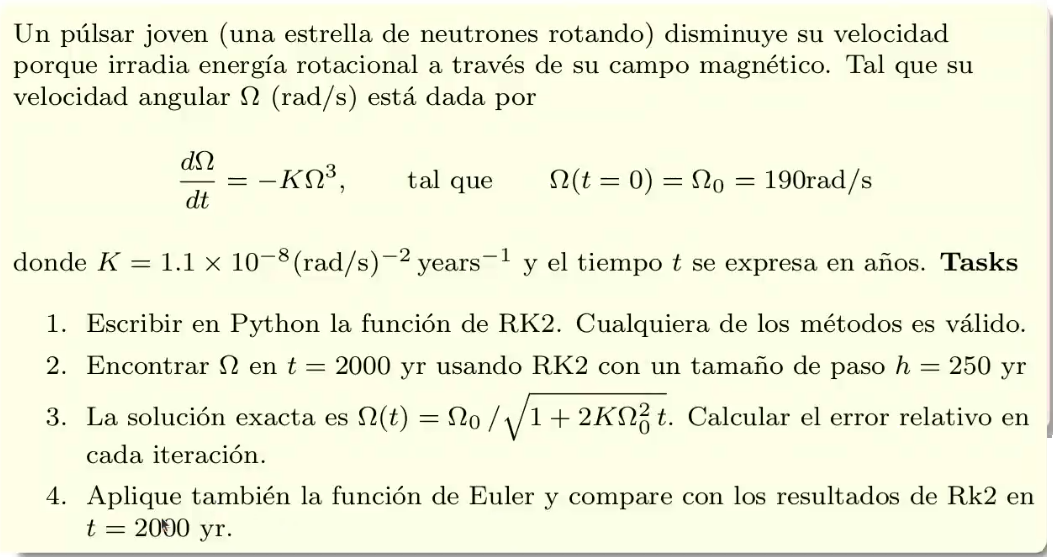

In [16]:
#Eduardo Perez
K,w0, h, tFinal = 1.1e-8, 190, 250, 2000

def f(w):
    return -K*(w**3)

def exactSolution(t):
    return w0/math.sqrt(1 + 2*K*(w0**2)*t)

def eulerStep(wCurrent, h):
    return wCurrent + f(wCurrent)*h

def heunStep(wCurrent, h):
    k1 = f(wCurrent)
    k2 = f(wCurrent + k1*h)
    return wCurrent + (0.5*k1 + 0.5*k2)*h

#Initial variables
t, wEuler, wHeun = 0, w0, w0

print("3)")
while t <= tFinal:
    wExact = exactSolution(t)

    errorEuler = abs((wExact-wEuler)/wExact)*100
    errorHeun = abs((wExact-wHeun)/wExact)*100

    #item 3)
    print(f"t(años): {t:6} | w exacta: {wExact} | Error Euler: {errorEuler} | Error Heun: {errorHeun}")

    if t == tFinal:
        break

    wEuler = eulerStep(wEuler,h)
    wHeun = heunStep(wHeun,h)
    t += h

print("2) y 4)")
print(f"w exacta: {wExact} rad/s")
print(f"w Heun: {wHeun} rad/s")
print(f"w Euler: {wEuler} rad/s")

3)
t(años):      0 | w exacta: 190.0 | Error Euler: 0.0 | Error Heun: 0.0
t(años):    250 | w exacta: 173.55036158035603 | Error Euler: 1.3901507080634599 | Error Heun: 0.07294402667545602
t(años):    500 | w exacta: 160.74588151006077 | Error Euler: 2.110143708436705 | Error Heun: 0.10731421472050214
t(años):    750 | w exacta: 150.41279541493623 | Error Euler: 2.508576945533429 | Error Heun: 0.12327912310367505
t(años):   1000 | w exacta: 141.84635320169573 | Error Euler: 2.7340284218730355 | Error Heun: 0.1298556116753
t(años):   1250 | w exacta: 134.59446237203414 | Error Euler: 2.8592833220679204 | Error Heun: 0.13143363740671238
t(años):   1500 | w exacta: 128.3520122015567 | Error Euler: 2.92348317052955 | Error Heun: 0.13029132840377827
t(años):   1750 | w exacta: 122.90464009778628 | Error Euler: 2.94914028003004 | Error Heun: 0.12766897703197394
t(años):   2000 | w exacta: 118.09673893279859 | Error Euler: 2.9498752120219 | Error Heun: 0.12426621512962575
2) y 4)
w exacta: 11